# Shared methodology — cross-region design notes

Florida and Sweden are two **independently built** pipelines (different
agencies, different file formats, different bugs found and fixed) that
happen to share the same two pieces of *reasoning* — this notebook is the
one place that reasoning is written down, so the per-region notebooks don't
each restate it. Everything region-specific (real coverage numbers, actual
quirks found in that region's own data, maps, worked examples) stays in the
region's own notebook and links back here instead of re-deriving the
general idea:

- **Barrier-treatment-timing tiers** (§1) — linked from
  [`florida/schools.ipynb`](florida/schools.ipynb) and
  [`sweden/schools.ipynb`](sweden/schools.ipynb).
- **Standardizing an outcome across a scale-breaking regime change** (§2) —
  linked from [`florida/assessments.ipynb`](florida/assessments.ipynb) and
  [`sweden/assessments.ipynb`](sweden/assessments.ipynb).

Shared plotting/display boilerplate itself also moved out of every
notebook into [`src/experiments/_setup.py`](_setup.py) — see its docstring
for the two-line import both regions now use.


In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "src").is_dir() and (c / "data").is_dir():
            return c
    raise FileNotFoundError(f"repo root not found from {Path.cwd()}")


ROOT = _find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiments._setup import BLUE, GREEN, GREY, RED, np, pd, plt

print("root:", ROOT)


root: /Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution


## 1. Barrier-treatment-timing tiers: point → `same_route` → `same_side`

Both regions match schools to noise barriers (road and/or rail) at up to
three tiers of increasing geometric strictness. Each tier is a **strict
refinement** of the last — tightening the match only ever removes schools
from "ever treated," it never adds any — which both regions verify
independently against their own real pair/rollup tables (`schools.ipynb`
§3 in each region's own notebook).

1. **Point-distance match** (`point`, algorithms 1–2) — for every school,
   find the nearest barrier of a given kind and its straight-line distance.
   A school counts as `ever_treated` if any barrier of that kind sits
   within a fixed match radius (Florida: arterial-network-gated; Sweden:
   1000m flat cutoff). This is the loosest tier: proximity alone, no
   check that the barrier and school are actually on the same physical
   road/track.
2. **`same_route`** (algorithm 4) — grows a corridor outward from the
   barrier along the real road/rail network graph (bounded network
   distance, not straight-line) and requires the school to fall inside
   that corridor. This is what actually confirms "same road/line," not
   just "nearby as the crow flies" — a school across a river or on a
   parallel road can be point-nearest to a barrier without being
   `same_route`.
3. **`same_side`** (algorithm 5) — among `same_route` pairs, additionally
   requires the school and the barrier to be on the **same side** of the
   road/track centerline (a signed offset from each point's nearest-segment
   projection). A wall on the far side of a highway from a school plausibly
   attenuates much less noise than a same-side wall at the same distance,
   so this is the tier meant to isolate genuine exposure, not just
   corridor membership.

**This tier is not free of failure modes, and each region found a
different one.** Florida found a real bug in `same_route`'s road-id
equality check (fixed with a network-distance-bounded corridor test — see
`florida/schools.ipynb` §7.4). Sweden found `same_side` itself is
unreliable *specifically for road* barriers: road barrier geometry turns
out to be stored as a copy of the road centerline itself (not an
independently surveyed wall position), collapsing the side comparison to
near-zero information — confirmed by checking the raw coordinates, not
assumed (see `sweden/schools.ipynb` §2). Rail doesn't have this problem in
either region's data. **The lesson generalizes: a network/geometric
matching tier is only as trustworthy as the raw geometry it's built from —
check the actual coordinates before trusting a derived comparison,
whichever region you're in.**


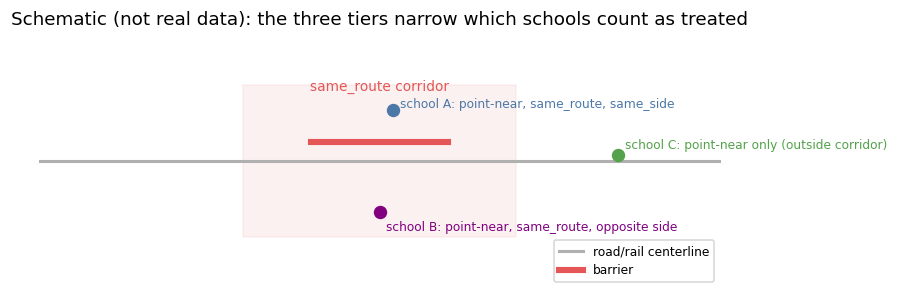

In [2]:
from matplotlib.patches import FancyArrow

fig, ax = plt.subplots(figsize=(8, 3))
# a toy road (not real data) purely to illustrate the three tiers geometrically
road_x = np.linspace(0, 10, 200)
ax.plot(road_x, np.zeros_like(road_x), color=GREY, linewidth=2, label="road/rail centerline")

barrier_x = np.linspace(4, 6, 50)
ax.plot(barrier_x, np.full_like(barrier_x, 0.15), color=RED, linewidth=4, label="barrier")

corridor = plt.Rectangle((3, -0.6), 4, 1.2, color=RED, alpha=0.08)
ax.add_patch(corridor)
ax.text(5, 0.55, "same_route corridor", ha="center", color=RED, fontsize=9)

ax.scatter([5.2], [0.4], color=BLUE, zorder=5, s=60)
ax.text(5.3, 0.42, "school A: point-near, same_route, same_side", fontsize=8, color=BLUE)
ax.scatter([5.0], [-0.4], color="purple", zorder=5, s=60)
ax.text(5.1, -0.55, "school B: point-near, same_route, opposite side", fontsize=8, color="purple")
ax.scatter([8.5], [0.05], color=GREEN, zorder=5, s=60)
ax.text(8.6, 0.1, "school C: point-near only (outside corridor)", fontsize=8, color=GREEN)

ax.set_ylim(-1, 1)
ax.set_xlim(0, 10)
ax.set_axis_off()
ax.set_title("Schematic (not real data): the three tiers narrow which schools count as treated")
ax.legend(loc="lower right", fontsize=8)
plt.show()


## 2. Standardizing an outcome across a scale-breaking regime change

Both regions' primary outcome is a school-level test/grade score measured
on a scale that **changed at least once** within the panel window — a
different test entirely (Florida: FCAT → FCAT 2.0 → FSA → FAST/B.E.S.T.,
four regimes) or a grading-scale reform (Sweden: IG/G/VG/MVG → A–F at the
2011 law / 2014 cohort boundary). Comparing raw scores across a break is
invalid: a raw-point trend line would show a level jump that's an artifact
of the scale change, not a real change in student achievement.

**The fix both regions independently converged on: z-score within
whatever grouping is internally scale-consistent, then treat the result as
one continuous outcome.** The grouping differs because the two scale
breaks have different shapes:

- **Florida (`z_mss`, `florida/assessments.ipynb` §4)**: z-scored within
  every `year × subject × grade` cell. Fine-grained because Florida's
  regime changes are frequent and don't line up with any other natural
  grouping — standardizing per cell differences out *every* regime break
  by construction, including ones not otherwise flagged.
- **Sweden (`meritvärde_z`, `sweden/assessments.ipynb` §3)**: z-scored
  within each side of the single 2014/15 reform boundary (`old_scale` /
  `new_scale`), pooling all schools and years on that side together. Coarser
  than Florida's per-cell approach because there's only one reform to
  correct for, and (unlike Florida) both sides of it already map to the
  *same* numeric range (0–320/340 either way) — the coarser grouping is a
  deliberate, documented judgment call among several considered, not the
  only one available (see the Sweden README's discussion of the two
  rejected alternatives: restricting to one side entirely, or never
  pooling).

**What z-scoring does *not* fix, in either region**: it equalizes the
*numeric* scale, not necessarily the underlying *construct*. A curriculum
or grading-criteria change can shift what a given z-score actually
represents even when the points range is held constant — both regions'
own notebooks flag this as an open caveat on their stitched outcome, not
something the standardization resolves.


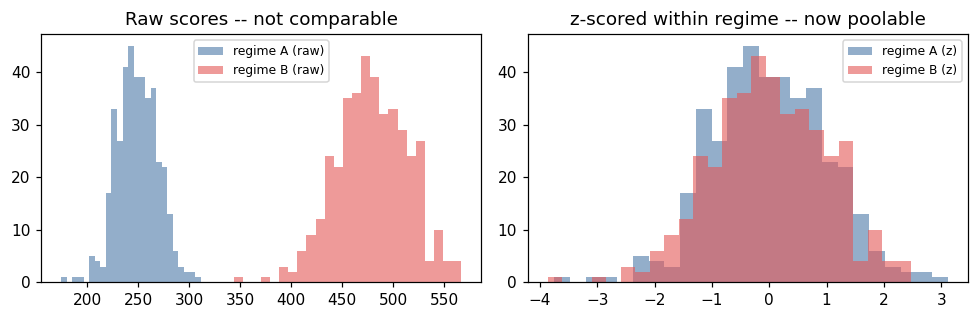

In [3]:
# Toy illustration (not real data): two regimes with different raw scales,
# comparable only after standardizing within each one separately.
rng = np.random.default_rng(0)
regime_a = rng.normal(250, 20, 400)   # e.g. an old test scale
regime_b = rng.normal(480, 35, 400)   # e.g. a new test scale, different range entirely

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].hist(regime_a, bins=25, alpha=0.6, color=BLUE, label="regime A (raw)")
axes[0].hist(regime_b, bins=25, alpha=0.6, color=RED, label="regime B (raw)")
axes[0].set_title("Raw scores -- not comparable")
axes[0].legend(fontsize=8)

z_a = (regime_a - regime_a.mean()) / regime_a.std()
z_b = (regime_b - regime_b.mean()) / regime_b.std()
axes[1].hist(z_a, bins=25, alpha=0.6, color=BLUE, label="regime A (z)")
axes[1].hist(z_b, bins=25, alpha=0.6, color=RED, label="regime B (z)")
axes[1].set_title("z-scored within regime -- now poolable")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


## Summary

- Both regions run the same three-tier barrier-matching logic
  (point → `same_route` → `same_side`); each region's own notebook
  verifies the nesting and reports its own real counts and its own
  region-specific data-quality findings.
- Both regions z-score their raw outcome within whatever grouping is
  internally scale-consistent, to build one continuous outcome across a
  regime break the raw numbers can't be compared across directly — the
  grouping granularity differs (Florida: per test cell; Sweden: per side
  of one reform) because the two breaks have different shapes, not because
  the underlying reasoning differs.
- Neither technique resolves construct-validity concerns (does the same
  z-score mean the same thing on both sides?) — both regions' own
  notebooks carry that caveat forward rather than treating standardization
  as a full fix.
